# EMPLOYEE PERFORMANCE PREDICTION

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# Handling imbalance
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Save model
import joblib

In [2]:
df = pd.read_csv("employees_final_dataset.csv")
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17412,64573,Technology,region_7,Bachelors,f,referred,2,30,5.0,6,1,0,81
17413,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51
17414,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51
17415,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51


In [3]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61


In [4]:
df.shape

(17417, 13)

In [5]:
df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met_more_than_80', 'awards_won',
       'avg_training_score'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17417 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17417 non-null  int64  
 1   department             17417 non-null  object 
 2   region                 17417 non-null  object 
 3   education              16646 non-null  object 
 4   gender                 17417 non-null  object 
 5   recruitment_channel    17417 non-null  object 
 6   no_of_trainings        17417 non-null  int64  
 7   age                    17417 non-null  int64  
 8   previous_year_rating   16054 non-null  float64
 9   length_of_service      17417 non-null  int64  
 10  KPIs_met_more_than_80  17417 non-null  int64  
 11  awards_won             17417 non-null  int64  
 12  avg_training_score     17417 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 1.7+ MB


In [7]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
count,17417.000000,17417.000000,17417.000000,16054.000000,17417.000000,17417.000000,17417.000000,17417.000000
mean,39083.491129,1.250732,34.807774,3.345459,5.801860,0.358845,0.023368,63.176322
std,22707.024087,0.595692,7.694046,1.265386,4.175533,0.479675,0.151074,13.418179
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19281.000000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,39122.000000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58838.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,75.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


In [8]:
target = "KPIs_met_more_than_80"
df[target].unique()

array([1, 0])

In [9]:
df[target].value_counts()

KPIs_met_more_than_80
0    11167
1     6250
Name: count, dtype: int64

In [10]:
df[target].dtype

dtype('int64')

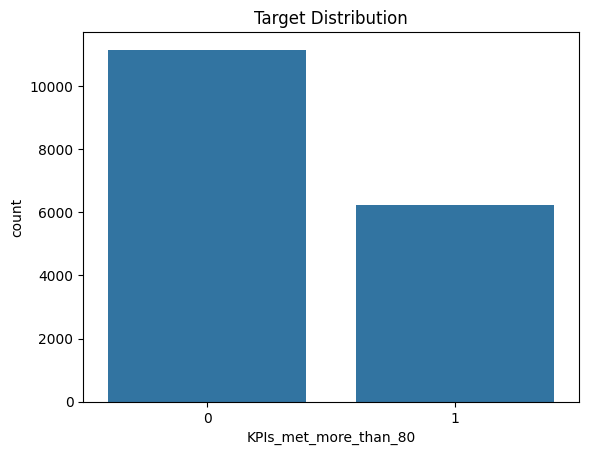

In [11]:
# EDA
sns.countplot(x=target, data=df)
plt.title("Target Distribution")
plt.show()

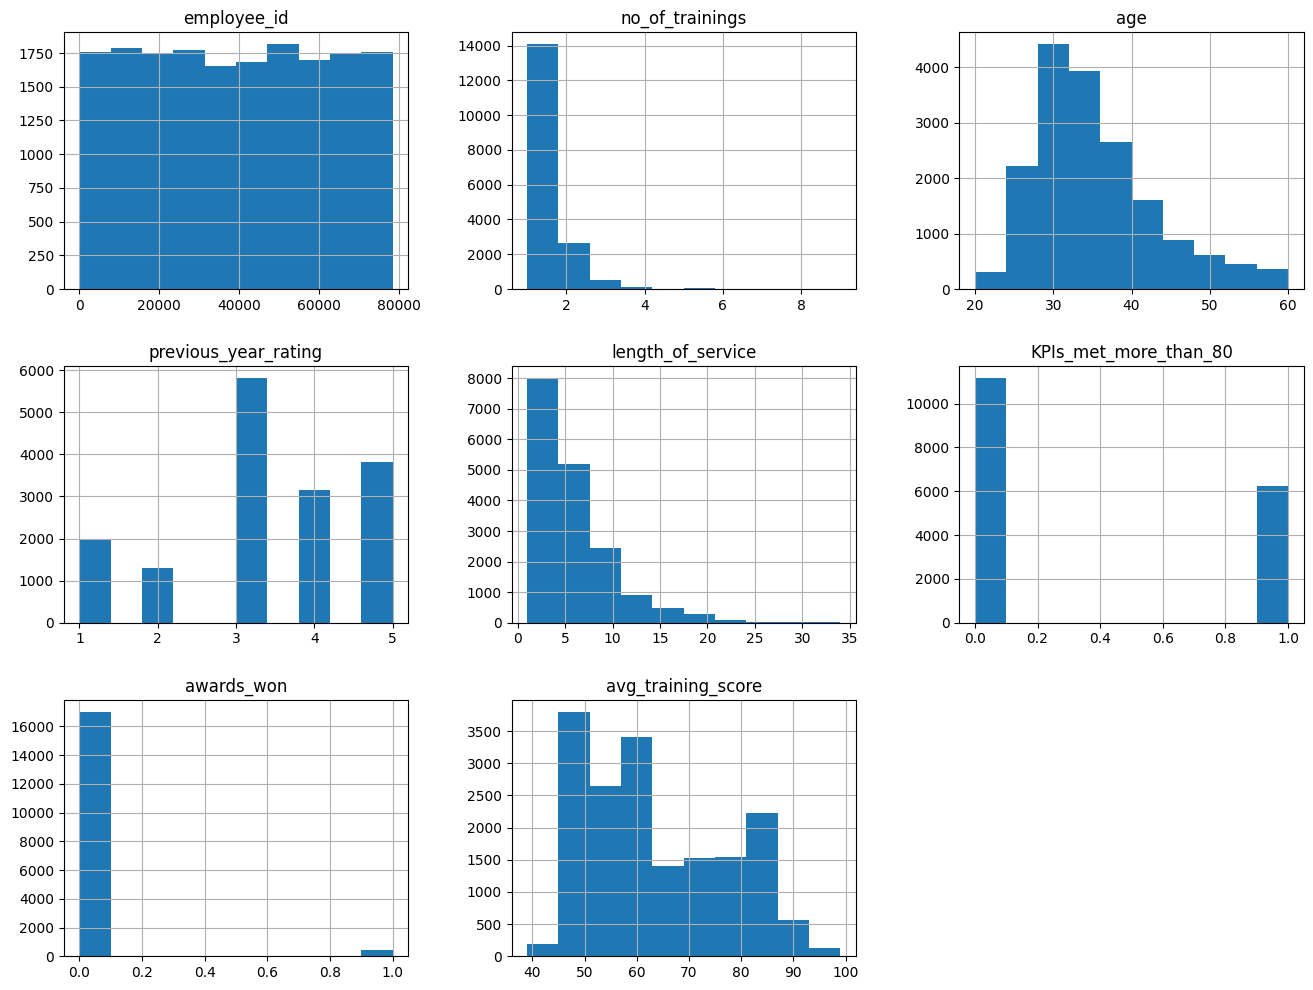

In [12]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].hist(figsize=(16,12))  
plt.show()

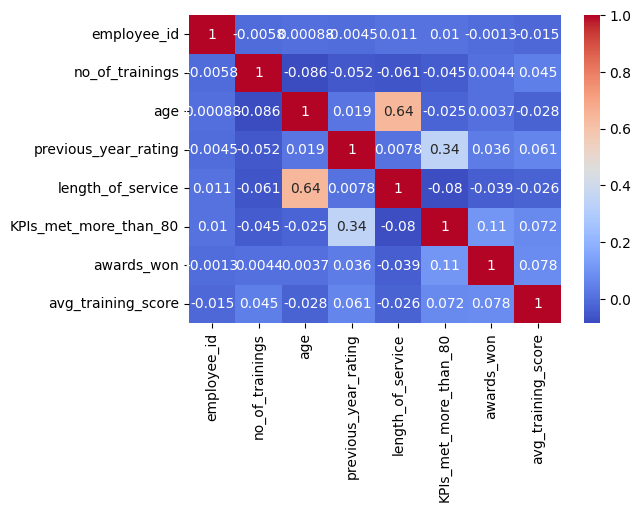

In [13]:
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

In [14]:
df.isnull().sum()

employee_id                 0
department                  0
region                      0
education                 771
gender                      0
recruitment_channel         0
no_of_trainings             0
age                         0
previous_year_rating     1363
length_of_service           0
KPIs_met_more_than_80       0
awards_won                  0
avg_training_score          0
dtype: int64

In [15]:
#  Identify numerical and categorical columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns


#  Fill numerical columns with median

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


#  Fill categorical columns with mode

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [16]:
df.isnull().sum()

employee_id              0
department               0
region                   0
education                0
gender                   0
recruitment_channel      0
no_of_trainings          0
age                      0
previous_year_rating     0
length_of_service        0
KPIs_met_more_than_80    0
awards_won               0
avg_training_score       0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(2)

In [18]:
df = df.drop_duplicates()

In [19]:
df.duplicated().sum()

np.int64(0)

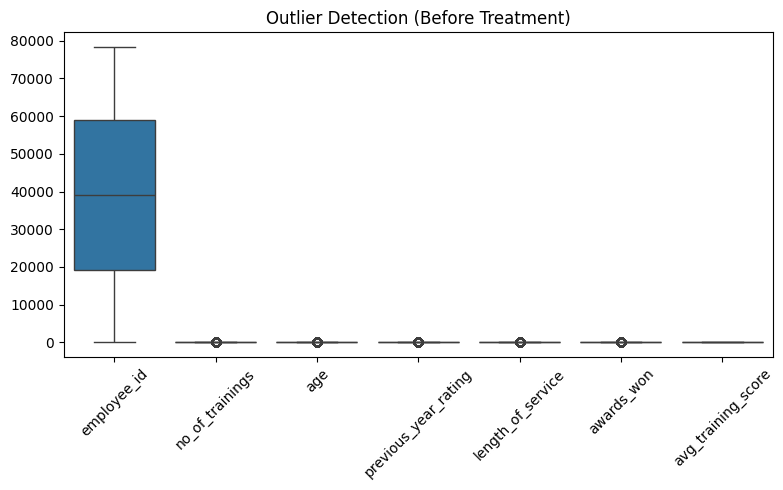

In [20]:
# OUTLIERS DETECT 

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove target column
if "KPIs_met_more_than_80" in numerical_cols:
    numerical_cols.remove("KPIs_met_more_than_80")

plt.figure(figsize=(8,5))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.title("Outlier Detection (Before Treatment)")
plt.tight_layout()
plt.show()

In [21]:
# Count Outliers Using IQR

outlier_count = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_count[col] = count

print("Outliers before treatment:")
print(outlier_count)

Outliers before treatment:
{'employee_id': 0, 'no_of_trainings': 3356, 'age': 453, 'previous_year_rating': 1974, 'length_of_service': 1083, 'awards_won': 407, 'avg_training_score': 0}


In [22]:
# Remove Outliers (Capping)

df_clean = df.copy()

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_clean[col] = np.where(df_clean[col] < lower, lower, df_clean[col])
    df_clean[col] = np.where(df_clean[col] > upper, upper, df_clean[col])

# Replace original dataframe
df = df_clean

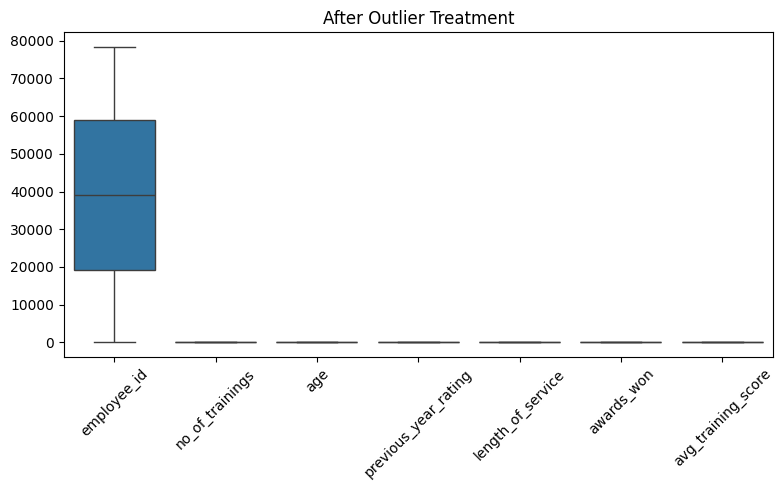

In [23]:
# Verify After Removal

plt.figure(figsize=(8,5))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.title("After Outlier Treatment")
plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_cols = ['department','region','education','gender','recruitment_channel']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
print(label_encoders['gender'].classes_)

['f' 'm']


In [25]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724.0,8,18,0,1,2,1.0,24.0,3.0,1.0,1,0.0,77.0
1,74430.0,2,28,0,0,0,1.0,31.0,3.0,5.0,0,0.0,51.0
2,72255.0,7,4,0,1,0,1.0,31.0,1.5,4.0,0,0.0,47.0
3,38562.0,5,11,0,0,0,1.0,31.0,2.0,9.0,0,0.0,65.0
4,64486.0,1,21,0,1,2,1.0,30.0,4.0,7.0,0,0.0,61.0


In [26]:
X = df_clean.drop(["KPIs_met_more_than_80", "employee_id"], axis=1)
y = df_clean["KPIs_met_more_than_80"]

In [27]:
X

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score
0,8,18,0,1,2,1.0,24.0,3.0,1.0,0.0,77.0
1,2,28,0,0,0,1.0,31.0,3.0,5.0,0.0,51.0
2,7,4,0,1,0,1.0,31.0,1.5,4.0,0.0,47.0
3,5,11,0,0,0,1.0,31.0,2.0,9.0,0.0,65.0
4,1,21,0,1,2,1.0,30.0,4.0,7.0,0.0,61.0
...,...,...,...,...,...,...,...,...,...,...,...
17410,7,24,0,1,0,1.0,42.0,3.0,10.0,0.0,53.0
17411,7,17,0,1,2,1.0,28.0,2.0,5.0,0.0,45.0
17412,8,31,0,0,1,1.0,30.0,5.0,6.0,0.0,81.0
17413,2,31,0,1,0,1.0,33.0,1.5,9.0,0.0,51.0


In [28]:
y

0        1
1        0
2        0
3        0
4        0
        ..
17410    0
17411    0
17412    1
17413    0
17416    1
Name: KPIs_met_more_than_80, Length: 17415, dtype: int64

In [29]:
y.value_counts()

KPIs_met_more_than_80
0    11165
1     6250
Name: count, dtype: int64

In [30]:
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

In [31]:
y.value_counts()

KPIs_met_more_than_80
1    11165
0    11165
Name: count, dtype: int64

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [34]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

train_pred = log_model.predict(X_train)
test_pred = log_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Train Accuracy: 0.6727496641289745
Test Accuracy: 0.6703985669502911


In [35]:
models = {
    "Logistic": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boost": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}


In [36]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    results.append([name, train_acc, test_acc])

results_df = pd.DataFrame(results, columns=["Model","Train Accuracy","Test Accuracy"])
results_df = results_df.sort_values(by="Test Accuracy", ascending=False)

print(results_df)

best_model_name = results_df.iloc[0]["Model"]
print("\nBest Model is:", best_model_name)

best_model = models[best_model_name]


            Model  Train Accuracy  Test Accuracy
5   Random Forest        0.999048       0.758621
8         XGBoost        0.841525       0.753918
7  Gradient Boost        0.758229       0.751455
6        AdaBoost        0.714566       0.707120
1             KNN        0.788289       0.697940
3   Decision Tree        0.999048       0.692342
4             SVM        0.703370       0.685849
0        Logistic        0.672750       0.670399
2     Naive Bayes        0.664353       0.663905

Best Model is: Random Forest


In [37]:
best_model_name = results_df.sort_values(by="Test Accuracy", ascending=False).iloc[0]["Model"]
print("\nBest Model is:", best_model_name)


Best Model is: Random Forest


In [38]:
best_model.fit(X_train, y_train)

RandomForestClassifier()

In [39]:
y_pred = best_model.predict(X_test)
y_pred

array([0, 0, 1, ..., 1, 0, 1], shape=(4466,))

In [40]:
print("\nBest Model Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Best Model Accuracy: 0.75794894760412

Confusion Matrix:

[[1727  472]
 [ 609 1658]]

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.79      0.76      2199
           1       0.78      0.73      0.75      2267

    accuracy                           0.76      4466
   macro avg       0.76      0.76      0.76      4466
weighted avg       0.76      0.76      0.76      4466



In [41]:
param_grid = {}

if best_model_name == "Random Forest":
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20]
    }
    grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)

elif best_model_name == "Decision Tree":
    param_grid = {
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }
    grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)

elif best_model_name == "XGBoost":
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 6]
    }
    grid = GridSearchCV(
        XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        param_grid,
        cv=5
    )

else:
    # If some other model selected
    grid = GridSearchCV(models[best_model_name], {}, cv=5)

grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10, 20],
                         'n_estimators': [100, 200]})

In [42]:
final_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)


Best Parameters: {'max_depth': 20, 'n_estimators': 200}
Best Cross Validation Score: 0.7518478297320735


In [43]:
final_pred = final_model.predict(X_test)

print("\nFinal Accuracy:", accuracy_score(y_test, final_pred))

print("\nFinal Confusion Matrix:\n")
print(confusion_matrix(y_test, final_pred))

print("\nFinal Classification Report:\n")
print(classification_report(y_test, final_pred))



Final Accuracy: 0.7590685176892074

Final Confusion Matrix:

[[1746  453]
 [ 623 1644]]

Final Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.79      0.76      2199
           1       0.78      0.73      0.75      2267

    accuracy                           0.76      4466
   macro avg       0.76      0.76      0.76      4466
weighted avg       0.76      0.76      0.76      4466



In [44]:
import joblib

joblib.dump(grid.best_estimator_, "final_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(X.columns.tolist(), "features.pkl")


['features.pkl']